In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from datetime import datetime, timedelta
from modules import smoothness_index

In [33]:
path_data = os.getcwd() + '/data/'
path_demand = path_data + 'output/csv/demand/'
path_loads =path_data + 'loads/'
path_generation = path_data + 'generators_profiles/'
path_losses = path_data + 'output/csv/losses/'
path_bess = path_data + 'output/csv/bess/'
dir_model = path_data + "/output/csv/models/"
dir_img = path_data + "/output/img/"

In [5]:
demand_NoOperation = path_demand + 'Demand_NoOperation_year_CondominioDosIpes.csv'
demand_smoothing = path_demand + 'Demand_Forecasting_bus013_year_CondominioDosIpes.csv'
demand_RL = path_demand + 'demand_train.csv'
# demand_RL = path_demand + 'rl_forecasting_results_test_PPO.csv'
bess_Forecasting = path_bess + 'BessPowers_Forecasting_bus013_year_CondominioDosIpes.csv'
bess_RL = path_bess + 'bess_train.csv'
# bess_RL = path_bess + 'rl_forecasting_bess_power_test_PPO.csv'

In [26]:
demand_values = pd.read_csv(demand_NoOperation)
demand_rl_values = pd.read_csv(demand_RL)
bess_rl_values = pd.read_csv(bess_RL)
demand_smoothing_values = pd.read_csv(demand_smoothing)
bess_forecasting_values = pd.read_csv(bess_Forecasting)
bess_forecasting_values['Timestep'] = pd.to_datetime(bess_forecasting_values['Timestep'])
bess_rl_values['Timestep'] = pd.to_datetime(bess_rl_values['Timestep'])
demand_values['Timestep'] = pd.to_datetime(demand_values['Timestep'])
demand_rl_values['Timestep'] = pd.to_datetime(demand_rl_values['Timestep'])
demand_smoothing_values['Timestep'] = pd.to_datetime(demand_smoothing_values['Timestep'])
date_ini = '2012-07-07 06:00'
date_end = '2012-07-11 06:00'
time = pd.date_range(start=date_ini, end=date_end, freq='5min')
demand_values = demand_values[(demand_values['Timestep'] >= date_ini) & (demand_values['Timestep'] <= date_end)]
demand_rl_values = demand_rl_values[(demand_rl_values['Timestep'] >= date_ini) & (demand_rl_values['Timestep'] <= date_end)]
bess_rl_values = bess_rl_values[(bess_rl_values['Timestep'] >= date_ini) & (bess_rl_values['Timestep'] <= date_end)]
bess_forecasting_values = bess_forecasting_values[(bess_forecasting_values['Timestep'] >= date_ini) & (bess_forecasting_values['Timestep'] <= date_end)]
demand_smoothing_values = demand_smoothing_values[(demand_smoothing_values['Timestep'] >= date_ini) & (demand_smoothing_values['Timestep'] <= date_end)]


In [27]:
print(f"Quantidade de épocas:{len(time)}")

Quantidade de épocas:1153


In [ ]:
sigma_normal,norm_normal = smoothness_index(demand_values['P(kW)'].values)
sigma_rl,norm_rl = smoothness_index(demand_rl_values['P(kW)'].values)
sigma_lstm,norm_lstm = smoothness_index(demand_smoothing_values['P(kW)'].values)
print(f'Smoothness Index - No Operation: {sigma_normal} - Normalized: {norm_normal}')
print(f'Smoothness Index - LSTM: {sigma_lstm} - Normalized: {norm_lstm}')
print(f'Smoothness Index - RL: {sigma_rl} - Normalized: {norm_rl}')

Smoothness Index - No Operation: 0.3358 - Normalized: 6327.0453
Smoothness Index - LSTM: 0.2255 - Normalized: 2025.2181
Smoothness Index - RL: 0.7536 - Normalized: 46126.36


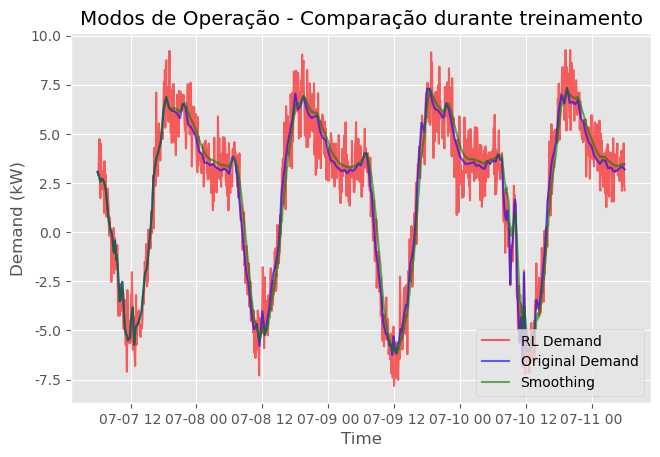

In [28]:
# plotting the demand values

plt.figure(figsize=(7.48, 4.8))
plt.plot(time, demand_rl_values['P(kW)'], label='RL Demand', color='red', alpha=0.6)
plt.plot(time, demand_values['P(kW)'], label='Original Demand', color='blue', alpha=0.6)
plt.plot(time,demand_smoothing_values['P(kW)'], label='Smoothing', color='green', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('Demand (kW)')
plt.title('Modos de Operação - Comparação durante treinamento')
plt.legend(loc='lower right')
plt.savefig(dir_img + 'demand_comparison.png',dpi = 300,bbox_inches='tight')

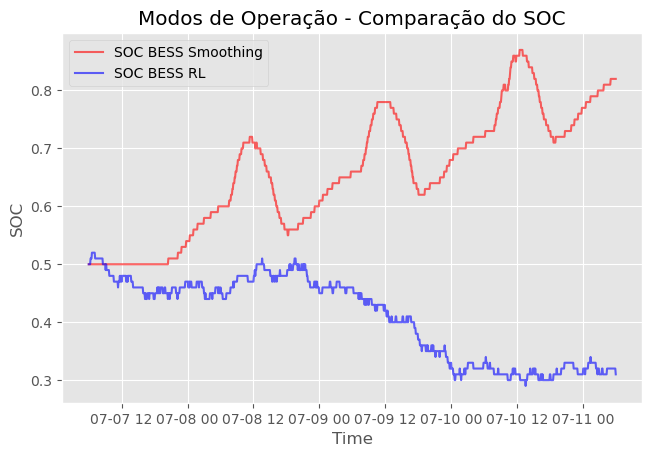

In [30]:
plt.figure(figsize=(7.48, 4.8))
plt.plot(time, bess_forecasting_values['SOC'], label='SOC BESS Smoothing', color='red', alpha=0.6)
plt.plot(time, bess_rl_values['SOC'], label='SOC BESS RL', color='blue', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('SOC')
plt.title('Modos de Operação - Comparação do SOC')
plt.legend()
plt.savefig(dir_img + 'soc_comparison.png',dpi = 300,bbox_inches='tight')

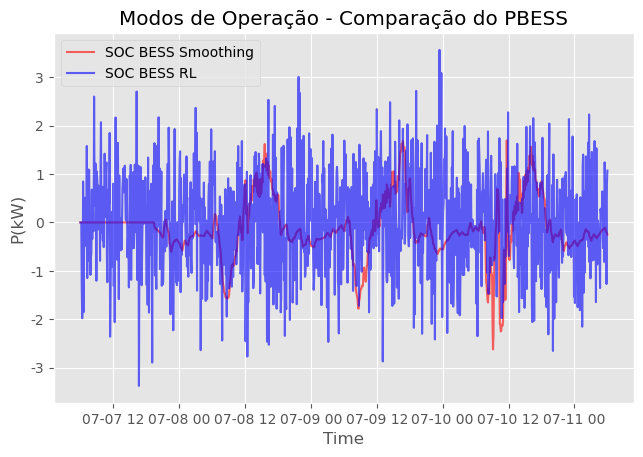

In [31]:
plt.figure(figsize=(7.48, 4.8))
plt.plot(time, bess_forecasting_values['P(kW)'], label='SOC BESS Smoothing', color='red', alpha=0.6)
plt.plot(time, bess_rl_values['P(kW)'], label='SOC BESS RL', color='blue', alpha=0.6)
plt.xlabel('Time')
plt.ylabel('P(kW)')
plt.title('Modos de Operação - Comparação do PBESS')
plt.legend()
plt.savefig(dir_img + 'pbess_comparison.png',dpi = 300,bbox_inches='tight')

## Cálculo das rewards

In [34]:
reward_weights = {"delta_sigma": 700.0, "delta_norm": 1000.0, "soc": 500.0}
# Load de reward dataframe
rewards_df = pd.read_csv(dir_model + 'rewards_train.csv')
rewards_df.head()


,delta_sigma,delta_norm,soc_penalty
0,0.6520,1.0435,0.0
1,-0.2090,-0.5444,0.0
2,0.1102,0.9090,0.0
3,0.6165,2.6605,0.0
4,0.0411,9.1175,0.0


In [36]:
rewards_df['reward'] = (reward_weights['delta_sigma'] * rewards_df['delta_sigma'] +
                        reward_weights['delta_norm'] * rewards_df['delta_norm'] +
                        reward_weights['soc'] * rewards_df['soc_penalty'])
rewards_df.head()

,delta_sigma,delta_norm,soc_penalty,reward
0,0.6520,1.0435,0.0,1499.90
1,-0.2090,-0.5444,0.0,-690.70
2,0.1102,0.9090,0.0,986.14
3,0.6165,2.6605,0.0,3092.05
4,0.0411,9.1175,0.0,9146.27


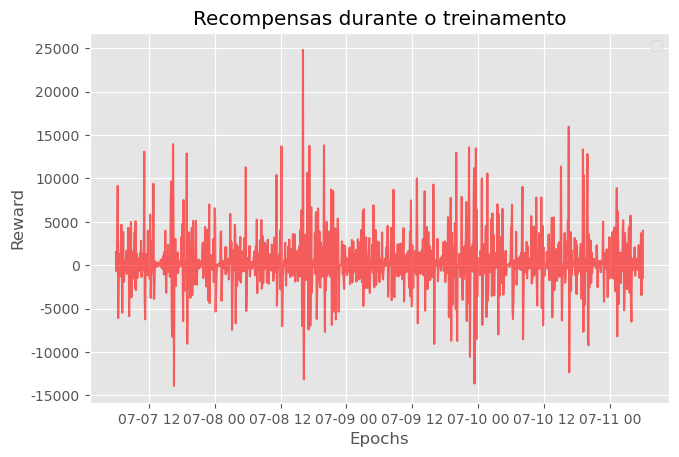

In [40]:
# Pega os valores entre 0:len(time)
rewards_df_period = rewards_df.iloc[0:len(time)]
plt.figure(figsize=(7.48, 4.8))
plt.plot(time, rewards_df_period['reward'], color='red', alpha=0.6)
plt.xlabel('Epochs')
plt.ylabel('Reward')
plt.title('Recompensas durante o treinamento')
plt.legend()
plt.savefig(dir_img + 'rewards_train.png',dpi = 300,bbox_inches='tight')

## Índices de Suavização durante o treinamento

In [42]:
indices_df = pd.read_csv(dir_model + 'indices_train.csv')
indices_df['Timestep'] = pd.to_datetime(indices_df['Timestep'])
indices_df = indices_df[(indices_df['Timestep'] >= date_ini) & (indices_df['Timestep'] <= date_end)]
indices_df.head()


,Timestep,Sigma,Norm
0,2012-07-07 06:00:00,0.000,0.0000
1,2012-07-07 06:05:00,0.000,0.0000
2,2012-07-07 06:10:00,0.000,0.0000
3,2012-07-07 06:15:00,0.652,1.0435
4,2012-07-07 06:20:00,0.443,0.4991


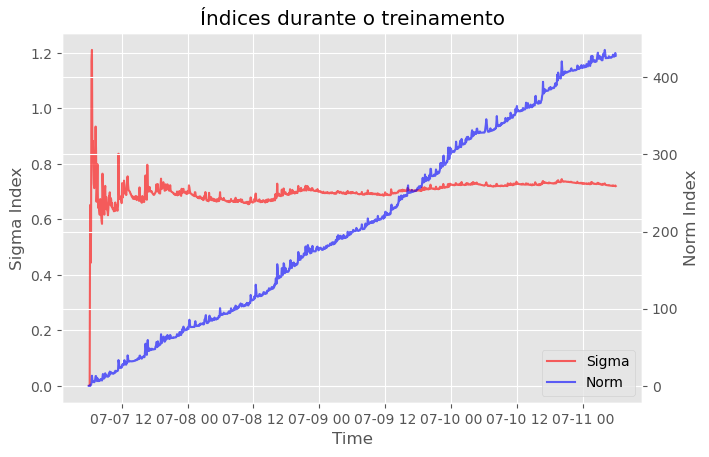

In [47]:
fig,ax1 = plt.subplots(figsize=(7.48, 4.8))
l1 = ax1.plot(time, indices_df['Sigma'], label='Sigma', color='red', alpha=0.6)
ax1.set_xlabel('Time')
ax1.set_ylabel('Sigma Index')
# Segundo eixo y
ax2 = ax1.twinx()
l2 = ax2.plot(time, indices_df['Norm'], label='Norm', color='blue', alpha=0.6)
ax2.set_ylabel('Norm Index')

lns = l1 + l2
labels = [l.get_label() for l in lns]
plt.legend(lns, labels, loc="lower right")

plt.title('Índices durante o treinamento')
plt.savefig(dir_img + 'indices_train.png',dpi =300,bbox_inches='tight')